<a href="https://colab.research.google.com/github/GuthierryMathias/e_commerce-Colab-/blob/main/e_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
#bibliotecas basicas para analise de dados

import pandas as pd
import numpy as np

#bibliotecas para graficos

import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para gráficos mais bonitos

plt.style.use('default')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)



### **Carregar Os Dados**

In [39]:
from google.colab import files
uploaded = files.upload()

Saving E_commerce.csv to E_commerce (1).csv


In [40]:
df = pd.read_csv('E_commerce.csv')


/tmp/ipykernel_32051/3883780178.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('E_commerce.csv')


In [41]:
print("Dados carregados!")
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")


Dados carregados!
Total de linhas: 51289
Total de colunas: 27


### **Conhecendo os dados**

In [42]:
print ('Primeiras linhas')
df.head()

Primeiras linhas


,Customer ID,Customer Name,Segment,City,State,Country,Region,Gender,Age,Education,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Browsing Time (min),Like,Share,Add to Cart
0,LS-001,Lane Daniels,Consumer,Brisbane,Queensland,Australia,Oceania,Male,22,Associate Degree,...,$140.00,2,0.05,$46.00,$4.60,Medium,14.7,1,1,1
1,IZ-002,Alvarado Kriz,Home Office,Berlin,Berlin,Germany,Central,Male,32,Bachelor,...,$211.00,3,0.03,$112.00,$11.20,Medium,15.0,0,0,1
2,EN-003,Moon Weien,Consumer,Porirua,Wellington,New Zealand,Oceania,Male,21,High School,...,$117.00,5,0.01,$31.20,$3.10,Critical,19.9,1,1,1
3,AN-004,Sanchez Bergman,Corporate,Kabul,Kabul,Afghanistan,Central Asia,Male,22,Bachelor,...,$118.00,2,0.05,$26.20,$2.60,High,15.8,1,1,1
4,ON-005,Rowe Jackson,Corporate,Townsville,Queensland,Australia,Oceania,Male,28,Associate Degree,...,$250.00,1,0.04,$160.00,$16.00,Critical,18.1,1,1,1


In [43]:
print ('Informacoes dados')
df.info()

Informacoes dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51289 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer ID          51289 non-null  object 
 1   Customer Name        51289 non-null  object 
 2   Segment              51289 non-null  object 
 3   City                 51289 non-null  object 
 4   State                51289 non-null  object 
 5   Country              51289 non-null  object 
 6   Region               51215 non-null  object 
 7   Gender               51289 non-null  object 
 8   Age                  51289 non-null  int64  
 9   Education            51289 non-null  object 
 10  Marital Status       51289 non-null  object 
 11  Order ID             51289 non-null  object 
 12  Order Date           51289 non-null  object 
 13  Months               51289 non-null  object 
 14  Ship Mode            51289 non-null  object 
 15  Product Category  

In [44]:
print ('Estatiticas basicas')
df.describe()

Estatiticas basicas


,Age,Browsing Time (min),Like,Share,Add to Cart
count,51289.000000,51289.000000,51289.000000,51289.000000,51289.000000
mean,31.315428,17.275973,0.567315,0.505274,0.666732
std,11.900634,9.674191,0.495453,0.499977,0.471386
min,18.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,9.300000,0.000000,0.000000,0.000000
50%,28.000000,16.500000,1.000000,1.000000,1.000000
75%,37.000000,24.600000,1.000000,1.000000,1.000000
max,70.000000,40.000000,1.000000,1.000000,1.000000


In [45]:
print ('Valores Faltantes')
Faltantes = df.isnull().sum()
Faltantes [ Faltantes > 0]

Valores Faltantes


,0
Region,74
Quantity,1
Order Priority,2


### **Limpeza de dados**

In [46]:
df_clean = df.copy()

In [47]:
df_clean = df_clean.dropna()

In [48]:
print(f"Dados após limpeza: {df_clean.shape[0]} linhas")
print(f"Valores faltantes agora: {df_clean.isnull().sum().sum()}")

Dados após limpeza: 51212 linhas
Valores faltantes agora: 0


In [49]:
duplicatas = df_clean.duplicated().sum()
print(f"Linhas duplicadas: {duplicatas}")

Linhas duplicadas: 0


### **Analise - Visao Geral Das Vendas**

In [50]:
# tratando dados da coluna Sales
df_clean['Sales'] = df_clean ['Sales'].astype(str).str.replace('$','',regex=False)
df_clean ['Sales'] = pd.to_numeric(df_clean['Sales'],errors='coerce')
df_clean.dropna(subset=['Sales'],inplace=True)

# Vendas Totais
vendas_totais = df_clean['Sales'].sum()
print(f"Vendas totais: R$ {vendas_totais:.2f}")


Vendas totais: R$ 8010534.00


In [51]:
# tratando dados da coluna Profit
df_clean['Profit'] = df_clean ['Profit'].astype(str).str.replace('$','',regex=False)
df_clean ['Profit'] = pd.to_numeric(df_clean['Profit'],errors='coerce')
df_clean.dropna(subset=['Profit'],inplace=True)

# Lucro total
lucro_total = df_clean['Profit'].sum()
print(f"Lucro total: R$ {lucro_total:.2f}")

Lucro total: R$ 3724061.90


In [52]:
# margem de lucro media

margem_lucro = (lucro_total / vendas_totais) * 100
print(f"Margem de lucro média: {margem_lucro:.2f}%")


Margem de lucro média: 46.49%


In [53]:
#tratando dados da coluna Quantity
df_clean['Quantity'] = df_clean ['Quantity'].astype(str).str.replace('$','',regex=False)
df_clean ['Quantity'] = pd.to_numeric(df_clean['Profit'],errors='coerce')
df_clean.dropna(subset=['Quantity'],inplace=True)

# Quantidade vendida
qtd_vendida = df_clean['Quantity'].sum()
print(f"Quantidade total vendida: {qtd_vendida:,.0f} unidades")

Quantidade total vendida: 3,724,062 unidades


In [54]:
# ticket medio

ticket_medio = vendas_totais / len(df_clean)
print(f"Ticket médio por pedido: R$ {ticket_medio:.2f}")


Ticket médio por pedido: R$ 156.42


### **Analise - Produtos mais Vendidos**

 1. T - Shirts                               - 407,416.0 unidades
 2. Titak watch                              - 354,567.0 unidades
 3. Running Shoes                            - 345,592.3 unidades
 4. Jeans                                    - 331,804.8 unidades
 5. Formal Shoes                             - 318,134.9 unidades
 6. Shirts                                   - 274,326.8 unidades
 7. Fossil Watch                             - 181,624.4 unidades
 8. Tyre                                     - 132,012.5 unidades
 9. Towels                                   - 131,012.3 unidades
10. Sofa Covers                              - 119,136.2 unidades


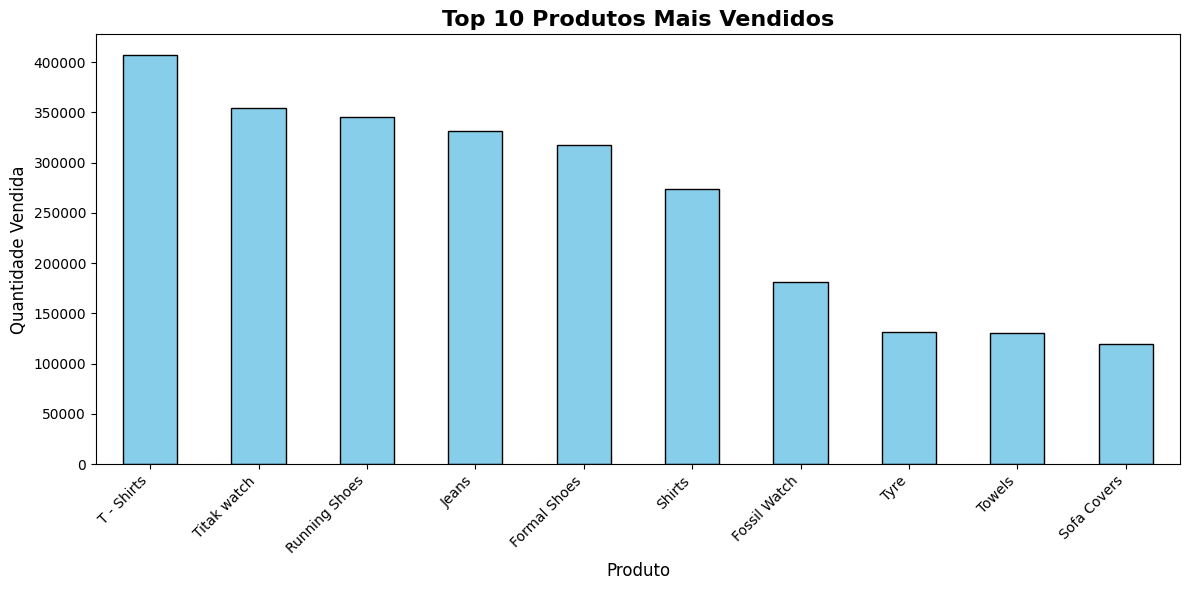

In [55]:
# Agrupar por produto e somar quantidade vendida
produtos_vendidos = df_clean.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

# Exibir em formato de tabela
for i, (produto, qtd) in enumerate(produtos_vendidos.items(), 1):
    print(f"{i:2d}. {produto[:40]:<40} - {qtd:>5,} unidades")

# Gráfico de barras
plt.figure(figsize=(12, 6))
produtos_vendidos.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 Produtos Mais Vendidos', fontsize=16, fontweight='bold')
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Quantidade Vendida', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 1. T - Shirts                               - R$ 407,416.00
 2. Titak watch                              - R$ 354,567.00
 3. Running Shoes                            - R$ 345,592.30
 4. Jeans                                    - R$ 331,804.80
 5. Formal Shoes                             - R$ 318,134.90
 6. Shirts                                   - R$ 274,326.80
 7. Fossil Watch                             - R$ 181,624.40
 8. Tyre                                     - R$ 132,012.50
 9. Towels                                   - R$ 131,012.30
10. Sofa Covers                              - R$ 119,136.20


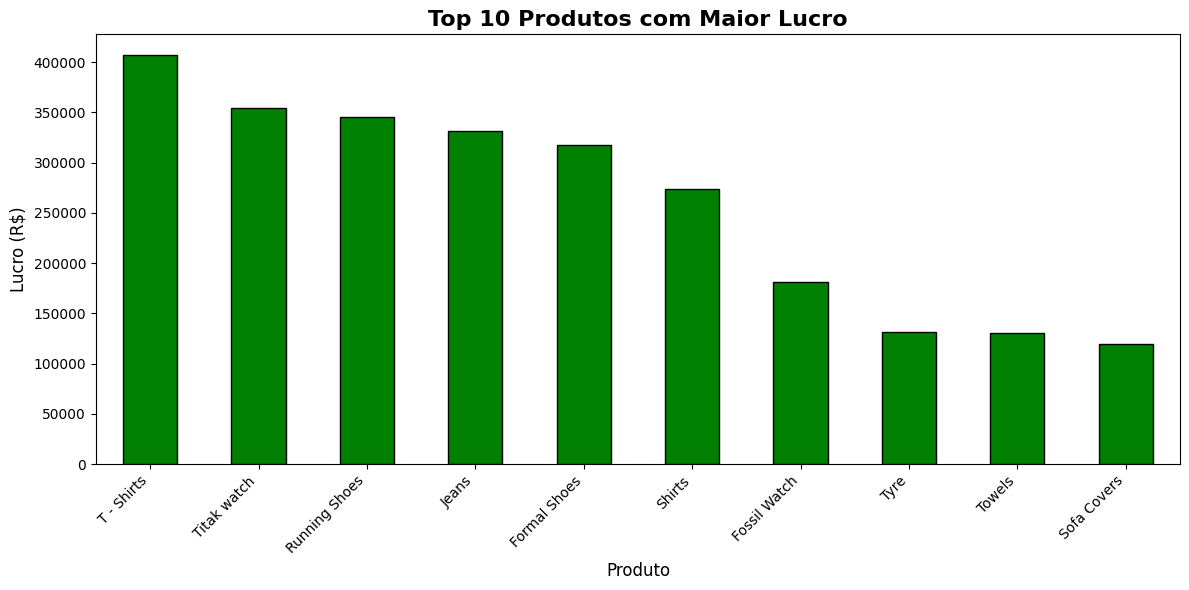

In [56]:
# Agrupar por produto e somar lucro
produtos_lucro = df_clean.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(10)

for i, (produto, lucro) in enumerate(produtos_lucro.items(), 1):
    print(f"{i:2d}. {produto[:40]:<40} - R$ {lucro:>10,.2f}")

# Gráfico
plt.figure(figsize=(12, 6))
cores = ['green' if x > 0 else 'red' for x in produtos_lucro]
produtos_lucro.plot(kind='bar', color=cores, edgecolor='black')
plt.title('Top 10 Produtos com Maior Lucro', fontsize=16, fontweight='bold')
plt.xlabel('Produto', fontsize=12)
plt.ylabel('Lucro (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Analise - Vendas Por Categoria**

Fashion              - R$ 5,204,344.00 (65.0%)
Home & Furniture     - R$ 1,318,547.00 (16.5%)
Auto & Accessories   - R$ 1,093,548.00 (13.7%)
Electronic           - R$ 394,095.00 (4.9%)


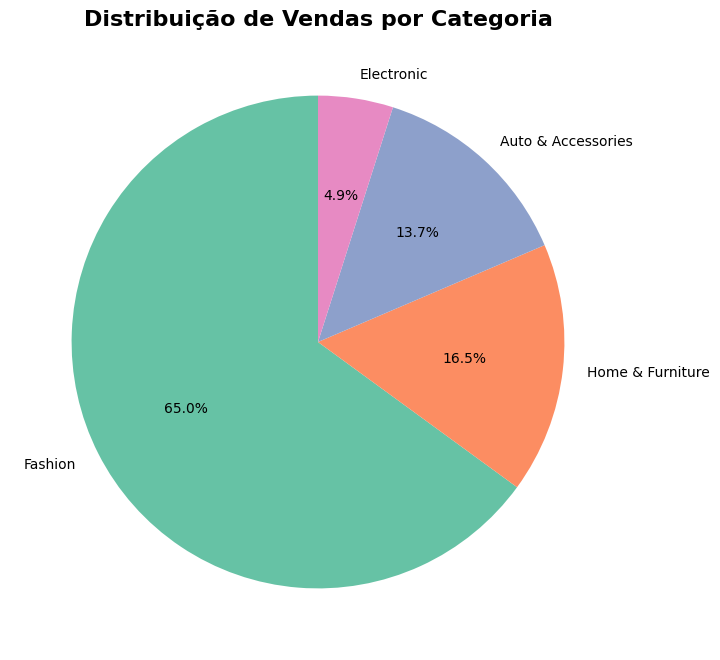

In [57]:
# Vendas por categoria
vendas_categoria = df_clean.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)

for categoria, valor in vendas_categoria.items():
    percentual = (valor / vendas_totais) * 100
    print(f"{categoria:<20} - R$ {valor:>10,.2f} ({percentual:.1f}%)")

# Gráfico de pizza
plt.figure(figsize=(10, 8))
plt.pie(vendas_categoria.values, labels=vendas_categoria.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição de Vendas por Categoria', fontsize=16, fontweight='bold')
plt.show()

Fashion              - R$ 2,480,392.40
Home & Furniture     - R$ 587,099.70
Auto & Accessories   - R$ 482,689.90
Electronic           - R$ 173,879.90


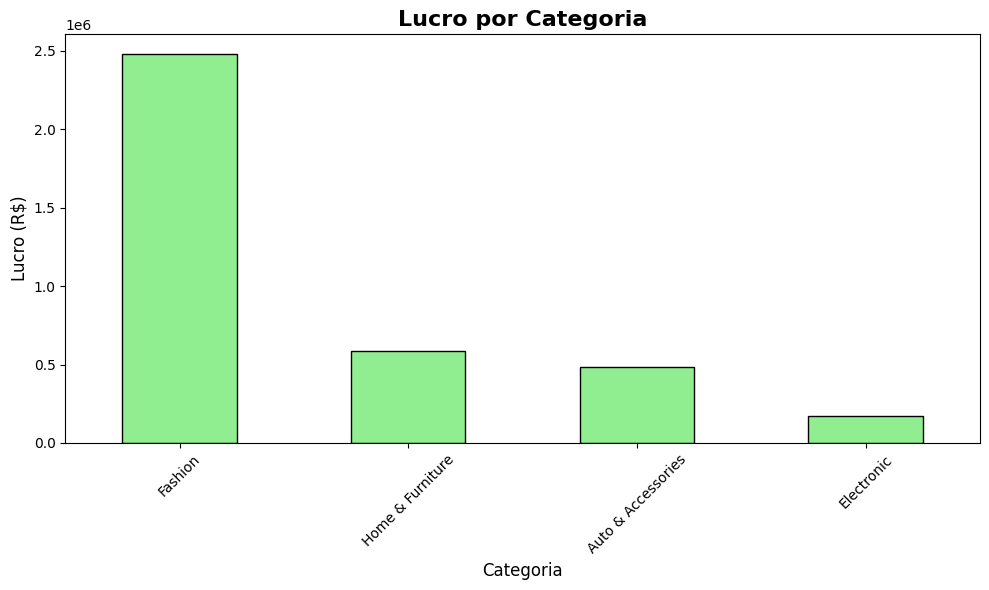

In [58]:
# Lucro por categoria
lucro_categoria = df_clean.groupby('Product Category')['Profit'].sum().sort_values(ascending=False)

for categoria, valor in lucro_categoria.items():
    print(f"{categoria:<20} - R$ {valor:>10,.2f}")

# Gráfico de barras
plt.figure(figsize=(10, 6))
lucro_categoria.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Lucro por Categoria', fontsize=16, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Lucro (R$)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Analise - Impacto do Desconto**

VENDAS POR FAIXA DE DESCONTO:
Até 10%         - R$ 8,010,284.00


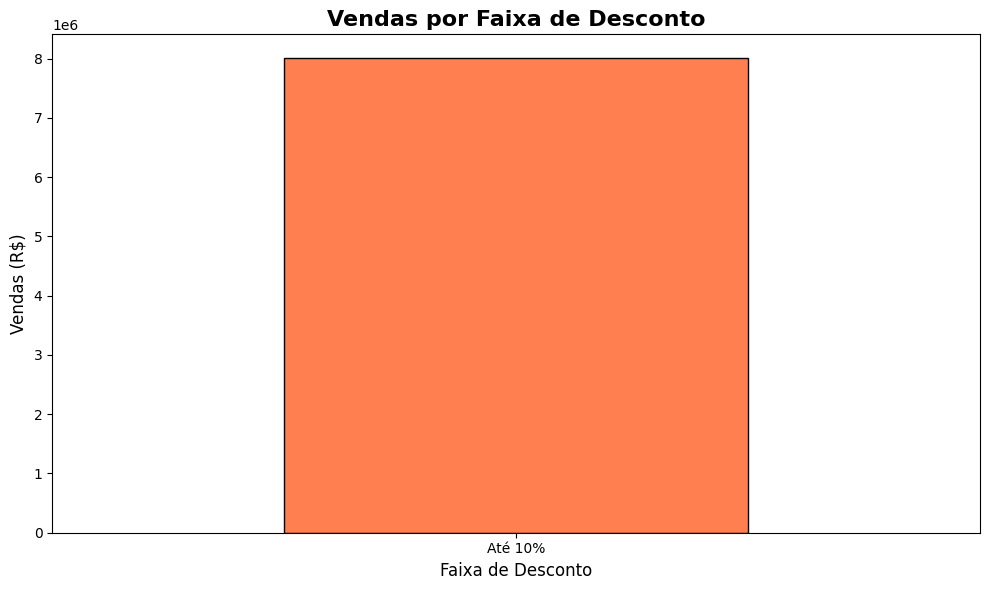

In [59]:
# Criar grupos de desconto
def faixa_desconto(desc):
    if desc == 0:
        return 'Sem desconto'
    elif desc <= 0.1:
        return 'Até 10%'
    elif desc <= 0.2:
        return '10-20%'
    else:
        return 'Acima de 20%'

df_clean['Discount'] = df_clean ['Discount'].astype(str).str.replace('$','',regex=False)
df_clean ['Discount'] = pd.to_numeric(df_clean['Discount'],errors='coerce')
df_clean.dropna(subset=['Discount'],inplace=True)

df_clean['Faixa_Desconto'] = df_clean['Discount'].apply(faixa_desconto)

# Vendas por faixa de desconto
vendas_por_desconto = df_clean.groupby('Faixa_Desconto')['Sales'].sum()

print("VENDAS POR FAIXA DE DESCONTO:")
for faixa, valor in vendas_por_desconto.items():
    print(f"{faixa:<15} - R$ {valor:>10,.2f}")

# Gráfico
plt.figure(figsize=(10, 6))
vendas_por_desconto.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Vendas por Faixa de Desconto', fontsize=16, fontweight='bold')
plt.xlabel('Faixa de Desconto', fontsize=12)
plt.ylabel('Vendas (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
print("Maior desconto nos dados:", df_clean['Discount'].max())
print("Todos os descontos:", sorted(df_clean['Discount'].unique()))

Maior desconto nos dados: 0.05
Todos os descontos: [np.float64(0.01), np.float64(0.02), np.float64(0.03), np.float64(0.04), np.float64(0.05)]



🔍 RELAÇÃO ENTRE DESCONTO E LUCRO:
Até 10%         - R$      72.72 (médio por pedido)


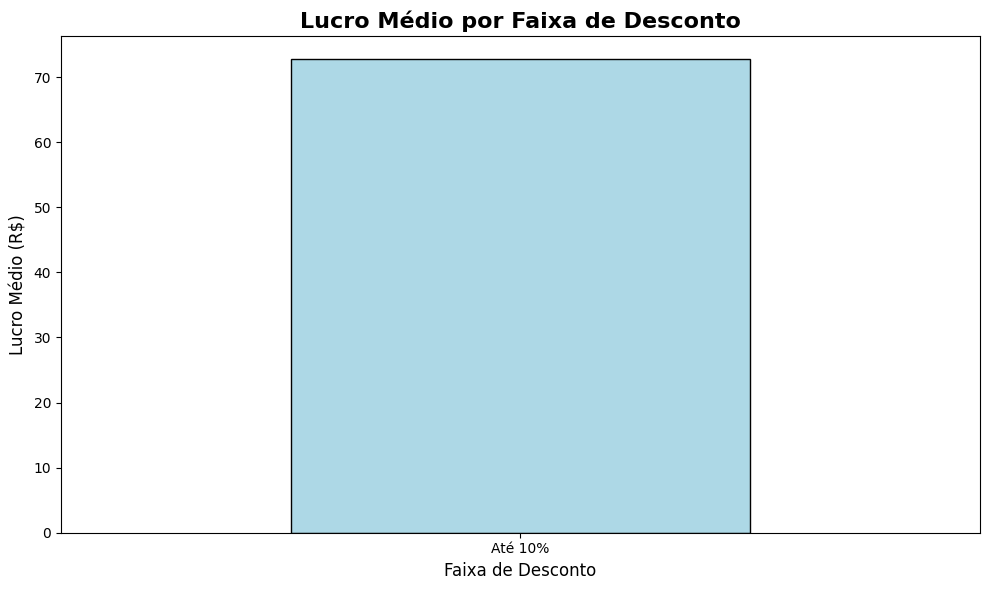

In [61]:
# Relação entre desconto e lucro
print("\n🔍 RELAÇÃO ENTRE DESCONTO E LUCRO:")

# Calcular lucro médio por faixa de desconto
lucro_medio_desconto = df_clean.groupby('Faixa_Desconto')['Profit'].mean()

for faixa, valor in lucro_medio_desconto.items():
    print(f"{faixa:<15} - R$ {valor:>10,.2f} (médio por pedido)")

# Gráfico de barras
plt.figure(figsize=(10, 6))
lucro_medio_desconto.plot(kind='bar', color='lightblue', edgecolor='black')
plt.title('Lucro Médio por Faixa de Desconto', fontsize=16, fontweight='bold')
plt.xlabel('Faixa de Desconto', fontsize=12)
plt.ylabel('Lucro Médio (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Analise - Vendas Por Regiao**

Central         - R$ 1,693,247.00 (21.1%)
South           - R$ 1,044,331.00 (13.0%)
North           - R$ 853,918.00 (10.7%)
Oceania         - R$ 661,474.00 (8.3%)
North Asia      - R$ 607,267.00 (7.6%)
West            - R$ 536,347.00 (6.7%)
Southeast Asia  - R$ 519,474.00 (6.5%)
EMEA            - R$ 511,891.00 (6.4%)
Africa          - R$ 505,774.00 (6.3%)
East            - R$ 469,506.00 (5.9%)
Central Asia    - R$ 363,864.00 (4.5%)
Caribbean       - R$ 181,880.00 (2.3%)
Canada          - R$  52,539.00 (0.7%)
So3th           - R$   8,772.00 (0.1%)


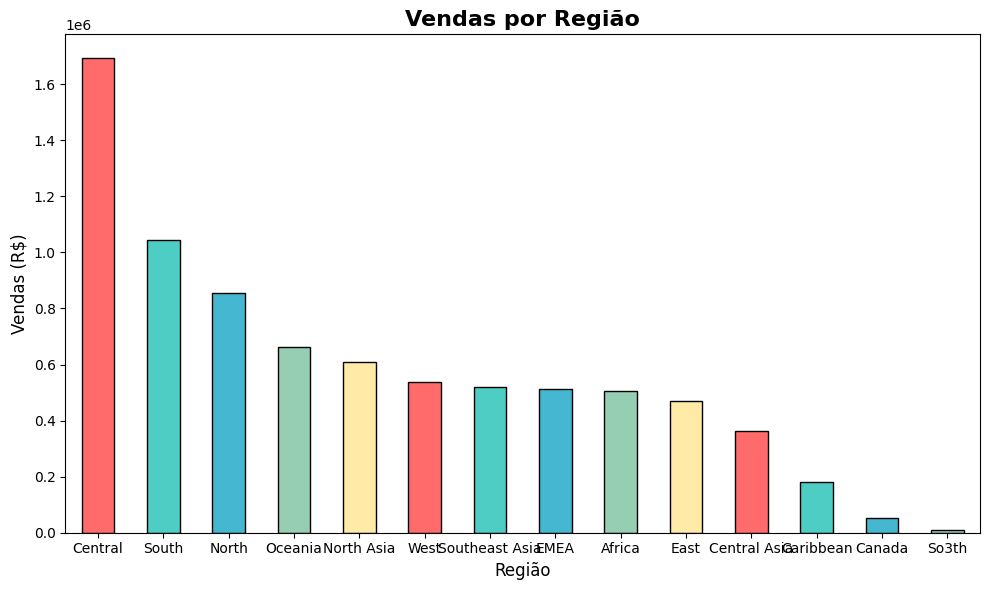

In [62]:
# Vendas por região
vendas_regiao = df_clean.groupby('Region')['Sales'].sum().sort_values(ascending=False)

for regiao, valor in vendas_regiao.items():
    percentual = (valor / vendas_totais) * 100
    print(f"{regiao:<15} - R$ {valor:>10,.2f} ({percentual:.1f}%)")

# Gráfico de barras
plt.figure(figsize=(10, 6))
cores_regiao = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
vendas_regiao.plot(kind='bar', color=cores_regiao[:len(vendas_regiao)], edgecolor='black')
plt.title('Vendas por Região', fontsize=16, fontweight='bold')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Vendas (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

North Asia      - R$      74.36 (médio por pedido)
Caribbean       - R$      74.04 (médio por pedido)
EMEA            - R$      73.51 (médio por pedido)
Central Asia    - R$      73.29 (médio por pedido)
North           - R$      73.21 (médio por pedido)
Southeast Asia  - R$      72.98 (médio por pedido)
South           - R$      72.60 (médio por pedido)
Oceania         - R$      72.56 (médio por pedido)
Canada          - R$      72.48 (médio por pedido)
West            - R$      72.40 (médio por pedido)
Africa          - R$      72.38 (médio por pedido)
Central         - R$      71.99 (médio por pedido)
East            - R$      71.67 (médio por pedido)
So3th           - R$      66.87 (médio por pedido)


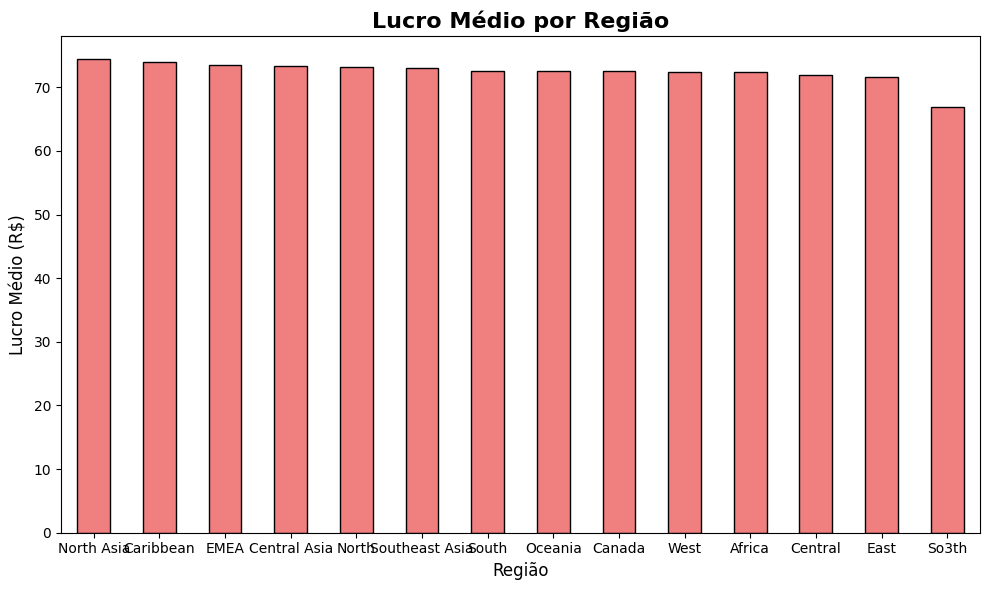

In [63]:
# Média de lucro por região

lucro_medio_regiao = df_clean.groupby('Region')['Profit'].mean().sort_values(ascending=False)

for regiao, valor in lucro_medio_regiao.items():
    print(f"{regiao:<15} - R$ {valor:>10,.2f} (médio por pedido)")

plt.figure(figsize=(10, 6))
lucro_medio_regiao.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Lucro Médio por Região', fontsize=16, fontweight='bold')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Lucro Médio (R$)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Resumo Final com Insights**

In [64]:
insights = [
    "1. DESEMPENHO GERAL:",
    f"   - Vendas totais: R$ {vendas_totais:,.2f}",
    f"   - Lucro total: R$ {lucro_total:,.2f}",
    f"   - Margem de lucro: {margem_lucro:.1f}%",
    "",
    "2. PRODUTOS DESTAQUE:",
    f"   - Mais vendido: {produtos_vendidos.index[0]} ({produtos_vendidos.values[0]:,} unidades)",
    f"   - Mais lucrativo: {produtos_lucro.index[0]} (R$ {produtos_lucro.values[0]:,.2f})",
    "",
    "3. CATEGORIAS:",
    f"   - Categoria que mais vende: {vendas_categoria.index[0]} ({vendas_categoria.values[0]/vendas_totais*100:.1f}% das vendas)",
    f"   - Categoria mais lucrativa: {lucro_categoria.index[0]}:",
    "",
    "4.  DESCONTOS:",
    f"   - Faixa de desconto mais usada: {vendas_por_desconto.index[0]}",
    "",
    "5.  REGIÕES:",
    f"   - Região que mais vende: {vendas_regiao.index[0]}",
    f"   - Região mais lucrativa: {lucro_medio_regiao.index[0]}",
]

for linha in insights:
    print(linha)

print("\n" + "=" * 60)
print(" RECOMENDAÇÕES:")
print("=" * 60)
print("• Invista nos produtos mais lucrativos para aumentar a margem")
print("• Revise descontos - eles podem estar reduzindo o lucro se aplicados em excesso.")
print("• Expanda estratégias de marketing nas regiões com maior potencial")
print("• Considere promoções específicas para as categorias com maior volume")
print("=" * 60)

1. DESEMPENHO GERAL:
   - Vendas totais: R$ 8,010,534.00
   - Lucro total: R$ 3,724,061.90
   - Margem de lucro: 46.5%

2. PRODUTOS DESTAQUE:
   - Mais vendido: T - Shirts (407,416.0 unidades)
   - Mais lucrativo: T - Shirts (R$ 407,416.00)

3. CATEGORIAS:
   - Categoria que mais vende: Fashion (65.0% das vendas)
   - Categoria mais lucrativa: Fashion:

4.  DESCONTOS:
   - Faixa de desconto mais usada: Até 10%

5.  REGIÕES:
   - Região que mais vende: Central
   - Região mais lucrativa: North Asia

 RECOMENDAÇÕES:
• Invista nos produtos mais lucrativos para aumentar a margem
• Revise descontos - eles podem estar reduzindo o lucro se aplicados em excesso.
• Expanda estratégias de marketing nas regiões com maior potencial
• Considere promoções específicas para as categorias com maior volume


In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
